
# 🎓 Student Performance Prediction Assignment
Applied AI & Machine Learning (CS-333)  
Instructor: Dr. Abbas Hussain  

---

## Objective
Predict **Performance Index** using multiple ML regression models.


# **Name:** Yousuf Uddin Ahmed
# **Roll Number:** ME1939
# **Section:** B

## Import Libraries

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
import time
%matplotlib inline
sns.set(color_codes=True)


## Load Dataset

In [2]:
# Load dataset
url = "https://raw.githubusercontent.com/AbbasHussain72/PNEC-CS-333-Applied-AI-ML/main/labs/Lab-03_LR_SVC/Student_Performance.csv"
df = pd.read_csv(url)
df.head(10)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


## Exploratory Data Analysis

In [3]:
# Check Type and info

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [4]:
# Check missing values

df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


the df.info() code in the previous cell already showed us that there are no missing values/null values. Still we can use df.isnull().sum() to find it seperately.

In [5]:
# Check Duplicate values
duplicate_rows = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows.shape)




number of duplicate rows:  (127, 6)


In [6]:
# Remove duplicates
df = df.drop_duplicates()
print("new shape after dropping duplicates:")
df.shape

new shape after dropping duplicates:


(9873, 6)

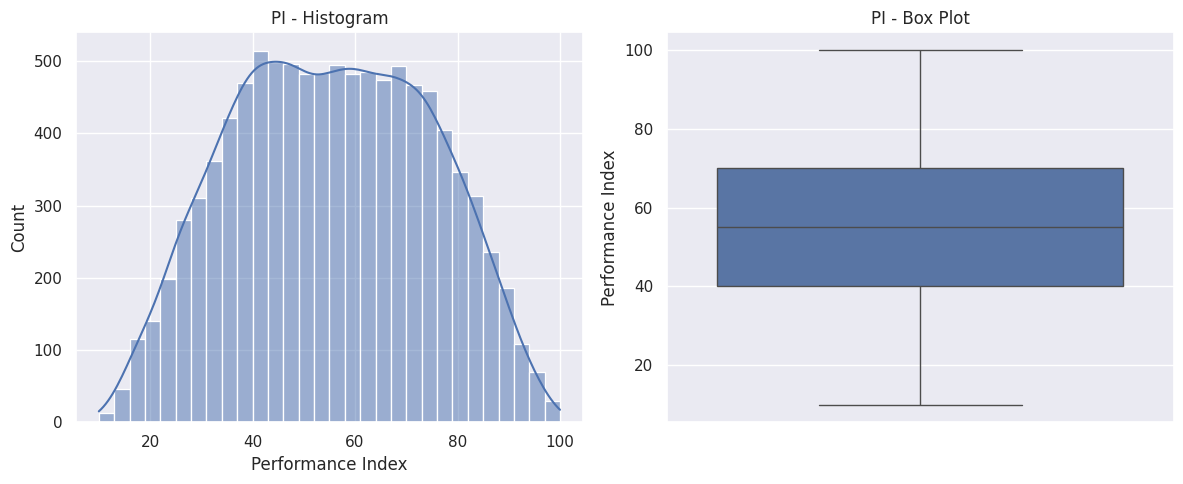

PI Skewness: -0.00
PI Kurotsis: -0.86


In [7]:
# Distibution Plot

plt.figure(figsize=(12, 5)) #Setting the figure size.

# Left: Histogram
plt.subplot(1, 2, 1)
sns.histplot(df["Performance Index"], kde=True, bins=30)
plt.title("PI - Histogram")
plt.xlabel("Performance Index", fontsize=12)

# Right: Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=df["Performance Index"])
plt.title("PI - Box Plot")
plt.ylabel("Performance Index", fontsize=12)

plt.tight_layout()
plt.show()

# Calculating skewness and kurtosis of the price distribution.
skewness = df["Performance Index"].skew()
kurtosis = df["Performance Index"].kurt()
print(f"PI Skewness: {skewness:.2f}")
print(f"PI Kurotsis: {kurtosis:.2f}")

A skewness value of zero indicates that the distribution of 'Performance Index' is highly symmetrical. This is favorable for building regression models. Based on our analysis, the 'Performance Index' is already very close to a normal distribution (skewness = -0.00). Therefore, applying a logarithmic transformation to reduce skewness is not necessary, as the current distribution is already well-suited for modeling without further transformation.

## Encoding (if needed)

In [8]:
# Encoding the 'Extracurricular Activities' coloumn using binary encoding

df_encoded = df.copy()

df_encoded['Extracurricular Activities'] = df_encoded['Extracurricular Activities'].map({
    'Yes': 1,
    'No': 0
})
df = df_encoded.copy()
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


## Visualization

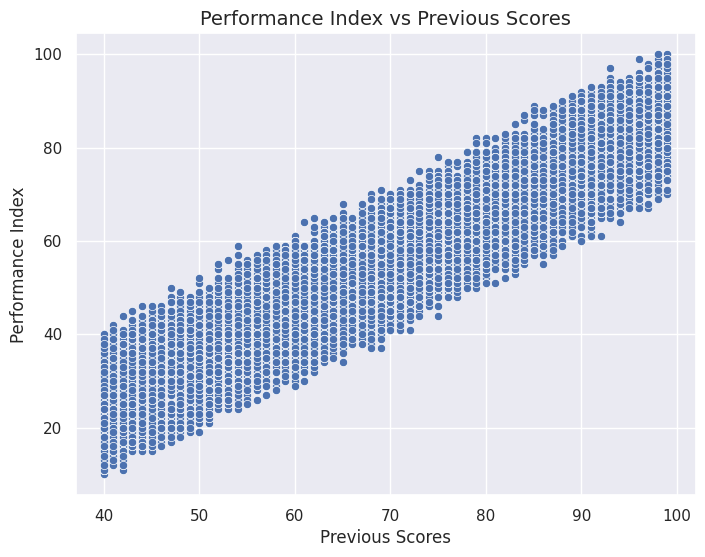

In [9]:
# Scatter plot for performance vs previous score

plt.figure(figsize=(8,6))
sns.scatterplot(x="Previous Scores", y="Performance Index", data=df)
plt.title("Performance Index vs Previous Scores", fontsize=14)
plt.xlabel("Previous Scores", fontsize=12)
plt.ylabel("Performance Index", fontsize=12)

plt.show()

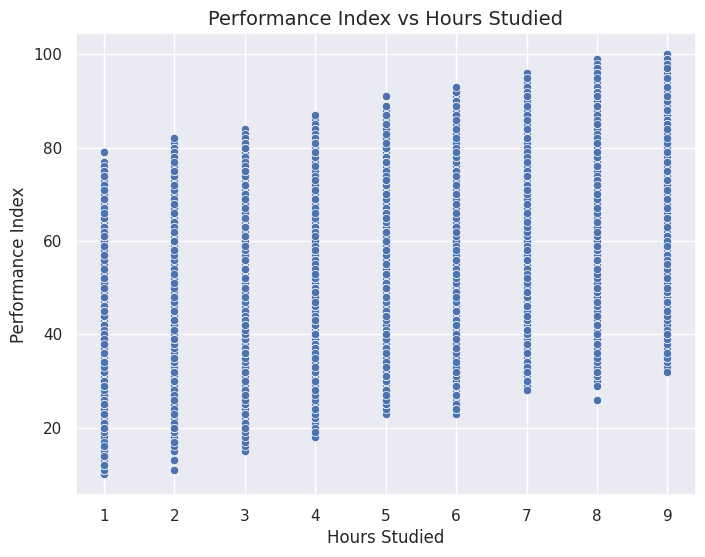

In [10]:
# Scatter plot for performance vs Hours Studied

plt.figure(figsize=(8,6))
sns.scatterplot(x="Hours Studied", y="Performance Index", data=df)
plt.title("Performance Index vs Hours Studied", fontsize=14)
plt.xlabel("Hours Studied", fontsize=12)
plt.ylabel("Performance Index", fontsize=12)

plt.show()

<Axes: >

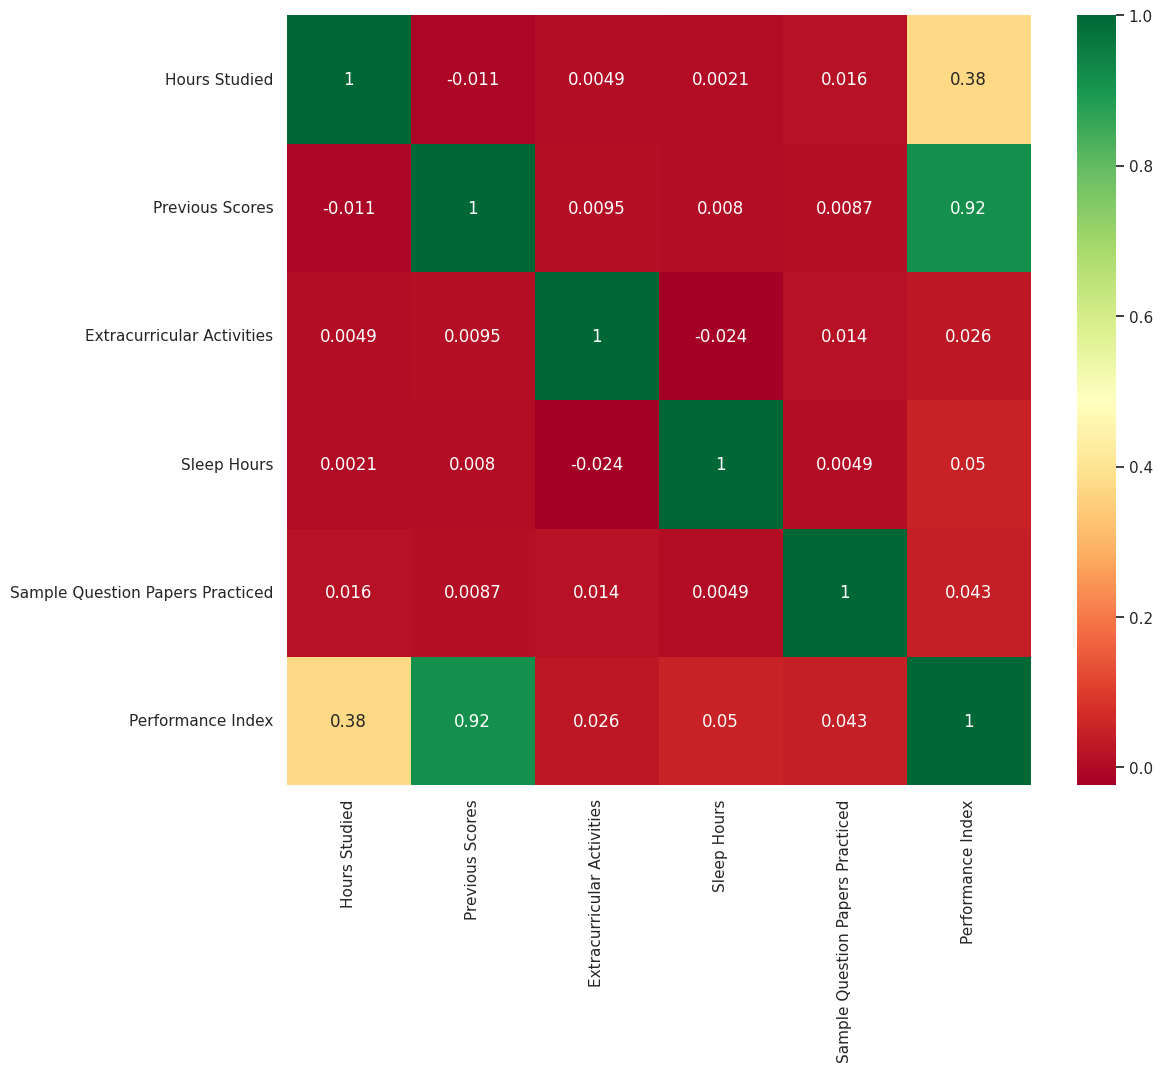

In [11]:
# Heatmap
c = df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(c,cmap="RdYlGn",annot=True)

## Correlation Analysis

In [12]:
# Compute correlation matrix
correlation_matrix = df.corr()
display(correlation_matrix)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.010676,0.004899,0.002131,0.015740,0.375332
Previous Scores,-0.010676,1.000000,0.009534,0.007975,0.008719,0.915135
Extracurricular Activities,0.004899,0.009534,1.000000,-0.024008,0.013839,0.026075
Sleep Hours,0.002131,0.007975,-0.024008,1.000000,0.004907,0.050352
Sample Question Papers Practiced,0.015740,0.008719,0.013839,0.004907,1.000000,0.043436
Performance Index,0.375332,0.915135,0.026075,0.050352,0.043436,1.000000


## Feature Selection

In [13]:
from sklearn.model_selection import train_test_split # For splitting the dataset.

X = df.drop("Performance Index", axis=1)
y = df["Performance Index"]


## Train-Test Split

In [14]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=11)


## Feature Scaling (If needed)

In [15]:
# For Scaling the features.

from sklearn.preprocessing import StandardScaler

# Scaling only numerical features(and non-binary)
numeric_cols = ["Hours Studied", "Previous Scores","Sleep Hours", "Sample Question Papers Practiced"]

scaler = StandardScaler()

# Initialize X_train_scaled and X_test_scaled as copies of X_train and X_test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fitting the standardScaler ONLY to the TRAINING data (X_train_scaled) and transforming it.
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_scaled[numeric_cols])

# Transforming the Test data ONLY (no fit here).
X_test_scaled[numeric_cols] = scaler.transform(X_test_scaled[numeric_cols])

print("--- First 10 Rows of Scaled Training Data ---")
# Displaying Scaled numerical columns for checking.
print(X_train_scaled[numeric_cols].head(10).to_markdown(index=False, numalign="center", stralign="center", floatfmt=".2f"))



--- First 10 Rows of Scaled Training Data ---
|  Hours Studied  |  Previous Scores  |  Sleep Hours  |  Sample Question Papers Practiced  |
|:---------------:|:-----------------:|:-------------:|:----------------------------------:|
|      0.39       |       -1.25       |     -0.90     |                0.49                |
|      1.54       |       -1.02       |     0.28      |               -0.21                |
|      0.77       |       1.47        |     1.46      |                0.49                |
|      0.00       |       -0.21       |     -0.31     |               -0.21                |
|      -0.39      |       0.55        |     -0.90     |               -0.21                |
|      0.77       |       -0.84       |     -1.49     |                0.84                |
|      0.39       |       0.55        |     -0.31     |                1.53                |
|      -1.54      |       0.95        |     0.28      |               -0.56                |
|      1.54       |     

In [16]:
#ONLY FOR SVRR
# Scale y
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()

Checking both scaled and original(non-scaled) data

In [17]:
# Checking both scaled and original(non-scaled) data

print("--- Original X_train (first 5 rows) ---")
display(X_train.head())

print("\n--- Scaled X_train (first 5 rows) ---")
display(X_train_scaled.head())

--- Original X_train (first 5 rows) ---


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
2765,6,48,1,5,6
1785,9,52,0,7,4
3651,7,95,0,9,6
6335,5,66,0,6,4
5181,4,79,0,5,4



--- Scaled X_train (first 5 rows) ---


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
2765,0.386609,-1.249506,1,-0.900944,0.488116
1785,1.544595,-1.017949,0,0.277968,-0.207998
3651,0.772604,1.471287,0,1.456880,0.488116
6335,0.000614,-0.207500,0,-0.311488,-0.207998
5181,-0.385381,0.545060,0,-0.900944,-0.207998


## Apply Regression Models (LR, SVR, Decision Tree,Random Forest, KNN)

### Linear Regression (LR)

In [18]:
#Applying linear regression

from sklearn.linear_model import LinearRegression

LR = LinearRegression()

start = time.time()
LR.fit(X_train_scaled, y_train)
train_time = time.time() - start

start = time.time()
y_pred_LR = LR.predict(X_test_scaled)
test_time = time.time() - start

In [19]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# R-squared
r2_LR = r2_score(y_test, y_pred_LR)
# RMSE
rmse_LR = np.sqrt(mean_squared_error(y_test, y_pred_LR))
# MAE
mae_LR = mean_absolute_error(y_test, y_pred_LR)

results = []
results.append(["Linear Regression", mae_LR, rmse_LR, r2_LR, train_time, test_time])

print("LR Model Performance:")
print("R² Score:", r2_LR)
print("RMSE:", rmse_LR)
print("MAE:", mae_LR)
print("TRAIN TIME:", train_time)
print("TEST TIME:", test_time)


LR Model Performance:
R² Score: 0.9890051566825925
RMSE: 2.027737786844955
MAE: 1.6165449497614988
TRAIN TIME: 0.005600690841674805
TEST TIME: 0.0020668506622314453


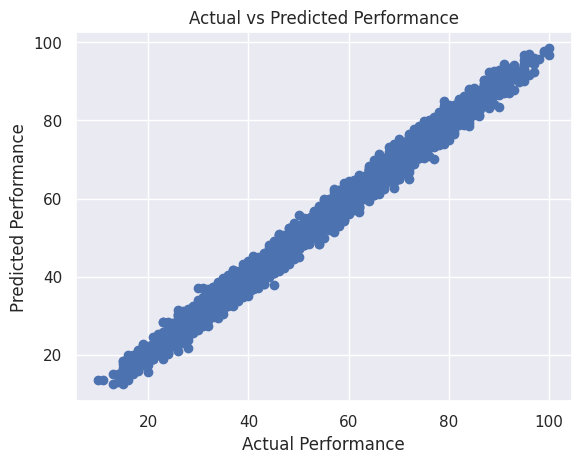

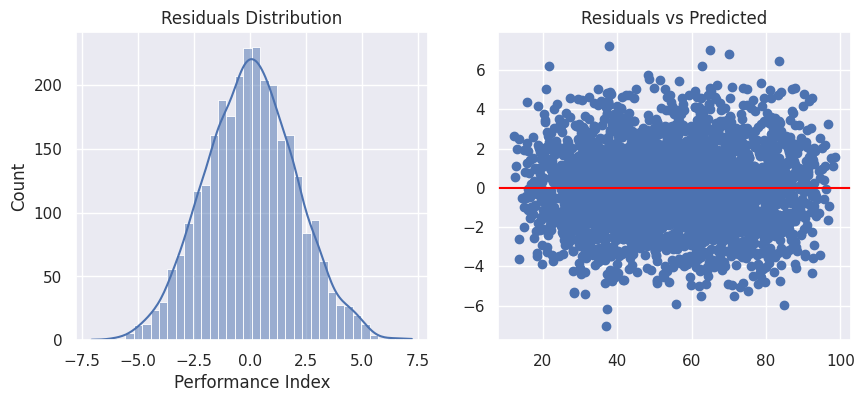

In [20]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_LR)

plt.xlabel("Actual Performance")
plt.ylabel("Predicted Performance")
plt.title("Actual vs Predicted Performance")
plt.show()


# Calculate residuals
residuals = y_test - y_pred_LR


# Histogram of residuals
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")

# Residuals vs Predicted
plt.subplot(1,2,2)
plt.scatter(y_pred_LR, residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Predicted")

plt.show()

### Support Vector Regression (SVR)

In [21]:
from sklearn.svm import SVR
# svr = SVR()
svr = SVR(kernel='rbf', C=100, gamma=0.01)

start = time.time()
svr.fit(X_train_scaled, y_train_scaled)
train_time = time.time() - start

start = time.time()
y_pred_svr = svr.predict(X_test_scaled)
test_time = time.time() - start

# Convert back to original scale
y_pred_svr = scaler_y.inverse_transform(y_pred_svr.reshape(-1,1))

r2_SVR = r2_score(y_test, y_pred_svr)
rmse_SVR = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_SVR = mean_absolute_error(y_test, y_pred_svr)

results.append(["SVR", mae_SVR, rmse_SVR, r2_SVR, train_time, test_time])

print("SVR Model Performance:")
print("R² Score:", r2_SVR)
print("RMSE:", round(rmse_SVR,3))
print("MAE:", round(mae_SVR,3))
print("TRAIN TIME:", train_time)
print("TEST TIME:", test_time)


SVR Model Performance:
R² Score: 0.9889540879558691
RMSE: 2.032
MAE: 1.62
TRAIN TIME: 7.272804498672485
TEST TIME: 1.5130953788757324


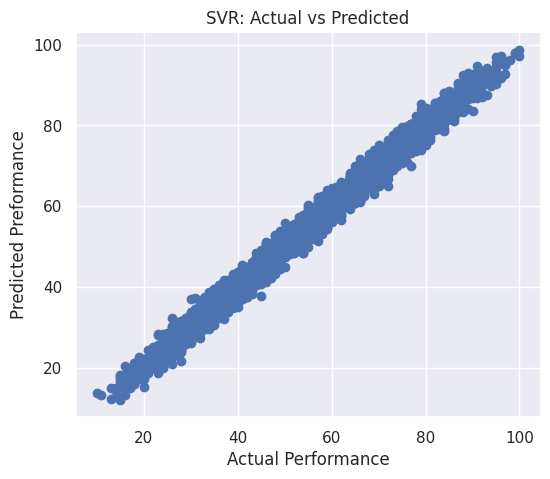

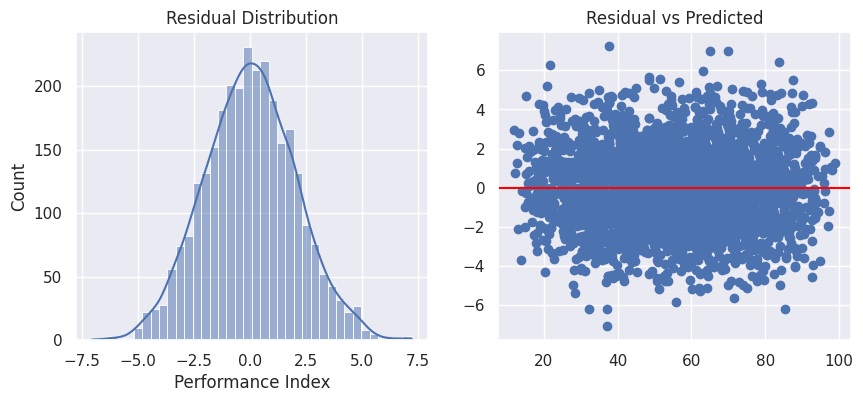

In [22]:
# Actual vs Predicted Plot

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_svr)
plt.xlabel("Actual Performance")
plt.ylabel("Predicted Preformance")
plt.title("SVR: Actual vs Predicted")
plt.show()


# Residual Analysis
y_pred_svr = y_pred_svr.ravel()
residuals = y_test - y_pred_svr

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.subplot(1,2,2)
plt.scatter(y_pred_svr, residuals)
plt.axhline(0, color='red')
plt.title("Residual vs Predicted")
plt.show()

### Decision Tree

In [23]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree model
dt = DecisionTreeRegressor(
    random_state=11
)

# Train the model
start = time.time()
dt.fit(X_train, y_train)
train_time = time.time() - start

# Make predictions
start = time.time()
y_pred_dt = dt.predict(X_test)
test_time = time.time() - start

# Calculate evaluation metrics
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)

results.append(["Decision Tree", mae_dt, rmse_dt, r2_dt, train_time, test_time])

print("Decision Tree Regression Results:")
print("R2 Score:", round(r2_dt,3))
print("RMSE:", round(rmse_dt,3))
print("MAE:", round(mae_dt,3))
print("TRAIN TIME:", train_time)
print("TEST TIME:", test_time)


Decision Tree Regression Results:
R2 Score: 0.975
RMSE: 3.04
MAE: 2.406
TRAIN TIME: 0.03541398048400879
TEST TIME: 0.003455638885498047


### Random Forest Regression (RF)

In [24]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest model
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=11
)

# Train the model
start = time.time()
rf.fit(X_train, y_train)
train_time = time.time() - start

# Make predictions
start = time.time()
y_pred_rf = rf.predict(X_test)
test_time = time.time() - start

# Calculate evaluation metrics
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

results.append(["Random Forest", mae_rf, rmse_rf, r2_rf, train_time, test_time])

print("Random Forest Regression Results:")
print("R2 Score:", round(r2_rf,3))
print("RMSE:", round(rmse_rf,3))
print("MAE:", round(mae_rf,3))
print("TRAIN TIME:", train_time)
print("TEST TIME:", test_time)


Random Forest Regression Results:
R2 Score: 0.985
RMSE: 2.355
MAE: 1.88
TRAIN TIME: 12.633085012435913
TEST TIME: 0.3744394779205322


### KNN Regression


In [25]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance"
)

# Train the model
start = time.time()
knn.fit(X_train_scaled, y_train)
train_time = time.time() - start

# Make predictions
start = time.time()
y_pred_knn = knn.predict(X_test_scaled)
test_time = time.time() - start

# Calculate evaluation metrics
r2_knn = r2_score(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn = mean_absolute_error(y_test, y_pred_knn)

results.append(["KNN", mae_knn, rmse_knn, r2_knn, train_time, test_time])

print("KNN Regression Results:")
print("R2 Score:", round(r2_knn,3))
print("RMSE:", round(rmse_knn,3))
print("MAE:", round(mae_knn,3))
print("TRAIN TIME:", train_time)
print("TEST TIME:", test_time)


KNN Regression Results:
R2 Score: 0.976
RMSE: 3.007
MAE: 2.41
TRAIN TIME: 0.009251832962036133
TEST TIME: 0.03787875175476074


## Answer the follwing
1) Explain how Random Forest Regressor predicts a continuous value.
Include:
What is a decision tree regressor?
What is bootstrapping?
How multiple trees are used?
How final output is calculated?




How Random Forest Regressor Predicts a Continuous Value:

What is a Decision Tree Regressor?
A Decision Tree Regressor is a supervised learning algorithm used to predict continuous values. It works by repeatedly splitting the dataset based on feature values in order to reduce prediction error, usually measured using Mean Squared Error (MSE). When a new data point is given, it travels through the tree from the root to a leaf node, and the prediction is typically the average of the target values of the training samples in that leaf.

What is Bootstrapping?
Bootstrapping is a sampling technique where the training dataset is randomly sampled with replacement to create multiple different datasets. This means some samples may appear multiple times while others may not appear at all. Each decision tree in the Random Forest is trained on a different bootstrap sample, which helps create diversity among the trees.

How Multiple Trees Are Used?
Random Forest builds many decision trees instead of relying on a single one. Each tree is trained on a different bootstrap sample of the data, and at every split only a random subset of features is considered. This randomness ensures the trees are different from each other and reduces overfitting.

How the Final Output Is Calculated?
For regression problems, each decision tree predicts a continuous value for a new data point. The Random Forest then calculates the final prediction by taking the average of the predictions from all trees. This averaging reduces variance and makes the model more stable and accurate compared to a single decision tree.

## Answer the follwing

2) Explain how KNN Regressor predicts output for a new data point.
Include:
What is K?
How neighbors are selected?
How final predicted value is calculated?

How KNN Regressor Predicts Output for a New Data Point:

What is K?
In KNN (K-Nearest Neighbors), K represents the number of nearest data points used to make a prediction. For example, if K = 5, the algorithm will consider the five closest training samples to the new data point.

How Neighbors Are Selected?
To find the nearest neighbors, the algorithm calculates the distance between the new data point and all training data points. The most commonly used distance metric is Euclidean distance. The K points with the smallest distances are selected as the nearest neighbors.

How the Final Predicted Value Is Calculated?
For regression tasks, the predicted value is calculated by taking the average of the target values of the K nearest neighbors. Some implementations may also use weighted averaging, where closer neighbors have a greater influence on the prediction.

## Visualize Best Model

In [26]:
# Select best model based on R2

best_r2 = max(r2_LR, r2_SVR, r2_knn, r2_dt, r2_rf)
print("Best R2 Score:", best_r2)

if best_r2 == r2_LR:
    print("Best Model: Linear Regression")
elif best_r2 == r2_SVR:
    print("Best Model: SVR")
elif best_r2 == r2_knn:
    print("Best Model: KNN")
elif best_r2 == r2_dt:
    print("Best Model: Decision Tree")
elif best_r2 == r2_rf:
    print("Best Model: Random Forest")

Best R2 Score: 0.9890051566825925
Best Model: Linear Regression


In [27]:
# Select best model based on R2, but excluding Linear Regression

second_best_r2 = max(r2_SVR, r2_knn, r2_dt, r2_rf)
print("Second Best R2 Score:", second_best_r2)

if second_best_r2 == r2_SVR:
    print("Second Best Model: SVR")
elif second_best_r2 == r2_knn:
    print("Second Best Model: KNN")
elif second_best_r2 == r2_dt:
    print("Second Best Model: Decision Tree")
elif second_best_r2 == r2_rf:
    print("Second Best Model: Random Forest")

Second Best R2 Score: 0.9889540879558691
Second Best Model: SVR


## Generate a Comparison Table of Regression Models

Your output should look like this:

| Model | MAE | RMSE | R2 Score |Training Time|Testing Time|
|-------|-----|------|----------|-------------|------------|
| Linear Regression | | | |||
| SVR | | | |||
| Decision Tree | | | |||
| Random Forest | | | |||
| KNN | | | |||

---

In [28]:
# Create table
results_df = pd.DataFrame(results,columns=["Model", "MAE", "RMSE", "R2 Score", "Training Time", "Testing Time"])

print(results_df.to_markdown(index=False, numalign="center", stralign="center", floatfmt=".5f"))

|       Model       |   MAE   |  RMSE   |  R2 Score  |  Training Time  |  Testing Time  |
|:-----------------:|:-------:|:-------:|:----------:|:---------------:|:--------------:|
| Linear Regression | 1.61654 | 2.02774 |  0.98901   |     0.00560     |    0.00207     |
|        SVR        | 1.61997 | 2.03244 |  0.98895   |     7.27280     |    1.51310     |
|   Decision Tree   | 2.40643 | 3.03961 |  0.97529   |     0.03541     |    0.00346     |
|   Random Forest   | 1.88027 | 2.35547 |  0.98516   |    12.63309     |    0.37444     |
|        KNN        | 2.40968 | 3.00744 |  0.97581   |     0.00925     |    0.03788     |
